In [ ]:
import os
import marimo as mo
import deepcor

os.chdir(mo.notebook_dir())  # all paths relative to the notebook

# DeepCor — simple training (CVAE v1)

Same high-level `deepcor.DeepCor` API as the v2 notebook — the **only**
difference is `model_version="v1"`. The original CVAE has no confound
conditioning, so `confounds` is optional and ignored here.

In [ ]:
# GPU check (optional)
deepcor.utils.check_gpu_and_speedup(tensor_size=(1000, 1000), n_iter=100)

In [ ]:
# ---- Data paths (the only thing you normally edit) ----
bids_path = "../Data/fMRI-Data/studyforrest-fmriprep/"

subs = sorted(d for d in os.listdir(bids_path) if d.startswith("sub-"))
s, r = 0, 4  # subject index, run
sub_id, run = subs[s], str(r)

session, task = "ses-localizer", "objectcategories"
space = "MNI152NLin2009cAsym"
base = os.path.join(bids_path, sub_id, session, "func")

epi_path = os.path.join(
    base, f"{sub_id}_{session}_task-{task}_run-{run}_bold_space-{space}_preproc.nii.gz"
)
gm_mask_path = os.path.join(bids_path, "mask_roi.nii")
cf_mask_path = os.path.join(bids_path, "mask_roni.nii")

output_dir = os.path.join(
    "../Data/DeepCor-Outputs", "forrest-simple-v1", f"S{s}-R{r}-cvae_v1"
)

for p in (epi_path, gm_mask_path, cf_mask_path):
    assert os.path.exists(p), f"missing: {p}"
print("EPI:", epi_path)
print("output_dir:", output_dir)

EPI: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-4_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
output_dir: ../Data/DeepCor-Outputs/forrest-simple-v1/S0-R4-cvae_v1


In [ ]:
# ---- Train + denoise ----
# Config is optional; omit it for sensible defaults. v1 ignores confounds.
#
# No `dashboard`/`on_epoch` => nothing is plotted interactively; the training
# dashboard is still saved to output_dir every epoch. A per-epoch progress
# line (subject/run, started, elapsed, ETA) is printed below.
denoiser = deepcor.DeepCor(model_version="v1")
denoiser.config.training.n_epochs = 5
denoiser.config.training.n_repetitions = 5

result = denoiser.fit_denoise(
    epi_path,
    gm_mask_path,
    cf_mask_path,
    confounds=None,      # v1 has no confound conditioning
    output_dir=output_dir,
    subject_idx=s,
    run_idx=r,
)

device is cuda:0
model_version is v1
Preparing training data...
obs_list.shape: (41147, 156)
noi_list.shape: (9105, 156)
upsampling noi_list_coords
obs_list.shape: (41147, 156)
noi_list.shape: (41147, 156)
S0R4 Training started at: 2026-06-17 12:05:17, elapsed: 0:00:30.0 Ens:1/5, E:5/5 ETA:0:02:00.0
S0R4 Training started at: 2026-06-17 12:05:17, elapsed: 0:01:07.7 Ens:2/5, E:5/5 ETA:0:01:41.5
S0R4 Training started at: 2026-06-17 12:05:17, elapsed: 0:01:45.5 Ens:3/5, E:5/5 ETA:0:01:10.3
S0R4 Training started at: 2026-06-17 12:05:17, elapsed: 0:02:23.5 Ens:4/5, E:5/5 ETA:0:00:35.8
S0R4 Training started at: 2026-06-17 12:05:17, elapsed: 0:03:01.1 Ens:5/5, E:5/5 ETA:0:00:00
Averaging ensemble predictions...


100%|███████████████████████████████████████████████████████████████| 5/5 [00:05<00:00,  1.07s/it]


signals averaged: 5
Saving comparison outputs (preproc, CompCor)...
Denoising complete! Output: ../Data/DeepCor-Outputs/forrest-simple-v1/S0-R4-cvae_v1/denoised_deepcor.nii.gz


Denoised: ../Data/DeepCor-Outputs/forrest-simple-v1/S0-R4-cvae_v1/denoised_deepcor.nii.gz
Preproc : ../Data/DeepCor-Outputs/forrest-simple-v1/S0-R4-cvae_v1/preproc.nii.gz
CompCor : ../Data/DeepCor-Outputs/forrest-simple-v1/S0-R4-cvae_v1/denoised_compcor.nii.gz


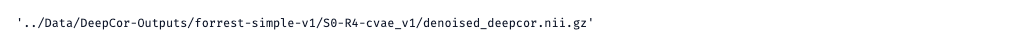

In [ ]:
print("Denoised:", result.denoised_path)
print("Preproc :", result.preproc_path)
print("CompCor :", result.compcor_path)
result.denoised_path

In [ ]:
# ---- Overlay dashboard: all repetitions layered onto one figure ----
# fit_denoise saves one track per repetition as track_rep_{rep}.pickle in
# output_dir. Reload them and overlay onto a single figure by threading the
# same `fig` through each call, then save it next to the other outputs.
# Depending on `result` ties this cell after training in marimo's DAG.
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

track_files = sorted(
    os.path.join(result.output_dir, f)
    for f in os.listdir(result.output_dir)
    if f.startswith("track_rep_") and f.endswith(".pickle")
)
tracks = [deepcor.data.load_pickle(track_file) for track_file in track_files]

this_fig = None
for this_track in tracks:
    try:
        this_fig = deepcor.visualization.show_dahsboard_v1_marimo(
            this_track, fig=this_fig, save_fig=False
        )
    except Exception as e:
        print(f"bad track: {e}")
if this_fig is not None:
    this_fig.savefig(
        os.path.join(result.output_dir, f"dashboard_S{s}_R{r}.png"),
        dpi=100,
        bbox_inches="tight",
    )
plt.show()